# SOC workbench with explicit finite spin-chain Hamiltonian

This workbench keeps the Step 3 bright/dark/phonon optical model, but replaces
the prescribed spin-correlation scalar by exact diagonalisation of a finite
S=1/2 spin-chain Hamiltonian.



In [21]:
from pathlib import Path
from datetime import datetime
import csv
import json
import sys

import matplotlib
import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().resolve()
for candidate in (PROJECT_ROOT, *PROJECT_ROOT.parents):
    if (candidate / "SolverV8").exists():
        PROJECT_ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate PROJECT_ROOT containing SolverV8.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from SolverV8 import LiouvilleSpectroscopySolver, SpectroscopyPlotter, standard_nq_protocol

RESULT_ROOT = PROJECT_ROOT / "SOC Model" / "result_3_0"
CODE_DIR = RESULT_ROOT / "code"
DATA_DIR = RESULT_ROOT / "Data"
FIGURES_DIR = RESULT_ROOT / "Figures"
ANALYSIS_DIR = RESULT_ROOT / "Analysis"
REPORT_DIR = RESULT_ROOT / "report"
SOURCE_NOTEBOOK = (
    PROJECT_ROOT
    / "SOC Model"
    / "Result_Test"
    / "etape_3"
    / "step3_dynamic_dimerisation_phonon.ipynb"
)

# Tau2 scan copy: do not create result folders on import.
# The code below keeps the workbench model/calculation definitions but leaves
# saving/report phases unused.



## Parameters and scan definitions



In [22]:
K_B_EV_K = 8.617333262145e-5
MU_B_EV_T = 5.7883818060e-5
matched_lambda_C = 0.01 / -0.443

model_params = {
    "Delta_dark": 0.90,
    "Delta_Bright": 1.00,
    "mu_B": 1.0,
    "mu_D": 0.0,
    "V0": 0.05,
    "lambda_delta": 0.20,
    "lambda_C": matched_lambda_C,
    "delta_source": "spin_peierls_mean_field",
    "delta_external": 0.0,
    "C1": 0.0,
    "spin_correlation_source": "exact_spin_chain",
    "n_bosons": 3,
    "omega_Q": 0.035,
    "g_Q": 0.010,
    "phonon_displacement_couples_to": "bright_dark",
    "T": 7.0,
    "T_SP_0": 14.0,
    "B": 0.0,
    "delta_0": 0.01,
    "beta": 0.5,
    "alpha_field": 0.004,
    "N_spin": 6,
    "J_spin_eV": 0.010,
    "J2_spin_eV": 0.0,
    "g_factor": 2.0,
    "boundary": "open",
    "N_k": 1,
    "gamma_orb": 0.0,
    "gamma_phonon": 0.0,
}

output_stem = "SOC_workbench"

solver_params = {
    "T": 0.0,
    "Eta": 0.005,
    "backend": "dense",
    "parallel_backend": "threading",
    "n_jobs": -1,
}

spectrum_params = {
    "N_w": 150,
    "omega1_rephasing_min": -1.35,
    "omega1_rephasing_max": -0.65,
    "omega1_unrephasing_min": 0.65,
    "omega1_unrephasing_max": 1.35,
    "omega3_min": 0.65,
    "omega3_max": 1.35,
    "tau2": 3.0,
}

tau2_values = np.linspace(0.0, 250.0, 15)  # eV^-1; 1 eV^-1 ~= 0.658 fs
RUN_TAU2_SCAN = True
PLOT_TAU2_SCAN = True



## Explicit spin-chain model



In [23]:
def spin_peierls_transition_temperature(B, T_SP_0, alpha_field):
    return max(0.0, float(T_SP_0) * (1.0 - float(alpha_field) * float(B) ** 2))


def spin_peierls_delta(T, B, T_SP_0, delta_0, beta, alpha_field):
    T_SP = spin_peierls_transition_temperature(B, T_SP_0, alpha_field)
    if T_SP > 0.0 and float(T) < T_SP:
        return float(delta_0) * (1.0 - float(T) / T_SP) ** float(beta)
    return 0.0


def resolve_delta(params):
    if params["delta_source"] == "spin_peierls_mean_field":
        return spin_peierls_delta(
            params["T"],
            params["B"],
            params["T_SP_0"],
            params["delta_0"],
            params["beta"],
            params["alpha_field"],
        )
    return float(params["delta_external"])


def single_site_spin_matrices():
    sx = 0.5 * np.array([[0.0, 1.0], [1.0, 0.0]], dtype=complex)
    sy = 0.5 * np.array([[0.0, -1.0j], [1.0j, 0.0]], dtype=complex)
    sz = 0.5 * np.array([[1.0, 0.0], [0.0, -1.0]], dtype=complex)
    return sx, sy, sz


def kron_all(operators):
    out = np.array([[1.0]], dtype=complex)
    for op in operators:
        out = np.kron(out, op)
    return out


def spin_site_operators(N_spin):
    sx, sy, sz = single_site_spin_matrices()
    ident = np.eye(2, dtype=complex)
    site_ops = []
    for site in range(N_spin):
        ops = []
        for alpha in (sx, sy, sz):
            factors = [ident] * N_spin
            factors[site] = alpha
            ops.append(kron_all(factors))
        site_ops.append(tuple(ops))
    return site_ops


def spin_dot_operator(site_ops, i, j):
    return sum(site_ops[i][axis] @ site_ops[j][axis] for axis in range(3))


def nearest_neighbor_pairs(N_spin, boundary):
    pairs = [(i, i + 1) for i in range(N_spin - 1)]
    if boundary == "periodic" and N_spin > 2:
        pairs.append((N_spin - 1, 0))
    return pairs


def next_nearest_neighbor_pairs(N_spin, boundary):
    pairs = [(i, i + 2) for i in range(N_spin - 2)]
    if boundary == "periodic" and N_spin > 3:
        pairs.extend([(N_spin - 2, 0), (N_spin - 1, 1)])
    return pairs


def build_spin_hamiltonian(params, delta):
    N_spin = int(params["N_spin"])
    boundary = str(params["boundary"])
    dim = 2**N_spin
    site_ops = spin_site_operators(N_spin)
    H = np.zeros((dim, dim), dtype=complex)
    bond_ops = []

    for i, j in nearest_neighbor_pairs(N_spin, boundary):
        bond = spin_dot_operator(site_ops, i, j)
        J_i = float(params["J_spin_eV"]) * (1.0 + ((-1.0) ** i) * float(delta))
        H += J_i * bond
        bond_ops.append(bond)

    for i, j in next_nearest_neighbor_pairs(N_spin, boundary):
        H += float(params["J2_spin_eV"]) * spin_dot_operator(site_ops, i, j)

    zeeman = sum(site_ops[i][2] for i in range(N_spin))
    H += float(params["g_factor"]) * MU_B_EV_T * float(params["B"]) * zeeman
    return H, bond_ops


def thermal_expectation_from_eigensystem(evals, evecs, operator, T):
    op_eigen_diag = np.einsum("ij,ij->j", evecs.conj(), operator @ evecs)
    if float(T) <= 0.0:
        e0 = float(np.min(evals))
        mask = np.isclose(evals, e0, atol=1e-12)
        return complex(np.mean(op_eigen_diag[mask]))
    beta = 1.0 / (K_B_EV_K * float(T))
    shifted = evals - float(np.min(evals))
    weights = np.exp(-beta * shifted)
    return complex(np.dot(weights, op_eigen_diag) / np.sum(weights))


def exact_spin_chain_observables(params, delta):
    H_spin, bond_ops = build_spin_hamiltonian(params, delta)
    hermitian_residual = float(np.max(np.abs(H_spin - H_spin.conj().T)))
    evals, evecs = np.linalg.eigh(H_spin)
    bond_values = [
        thermal_expectation_from_eigensystem(evals, evecs, op, params["T"]).real
        for op in bond_ops
    ]
    return {
        "C1": float(np.mean(bond_values)),
        "bond_C1_values": np.array(bond_values),
        "spin_dimension": int(H_spin.shape[0]),
        "spin_hilbert_dimension_expected": int(2 ** int(params["N_spin"])),
        "spin_hermitian_residual": hermitian_residual,
        "spin_ground_energy_eV": float(evals[0]),
        "spin_gap_eV": float(evals[1] - evals[0]) if len(evals) > 1 else 0.0,
    }



## Projected optical bright/dark/phonon model



In [24]:
def static_bright_dark_mixing(params, delta, C1):
    return (
        float(params["V0"])
        + float(params["lambda_delta"]) * float(delta)
        + float(params["lambda_C"]) * float(C1)
    )


def lowering_operator(n):
    op = np.zeros((n, n), dtype=complex)
    for upper in range(1, n):
        op[upper - 1, upper] = np.sqrt(upper)
    return op


def build_spin_resolved_projected_model(params):
    N_k = int(params["N_k"])
    if N_k != 1:
        raise NotImplementedError("result_3_0 keeps N_k=1 to isolate the spin-chain control.")
    k_array = np.array([0.0])
    k_weights = np.ones(1)

    delta = resolve_delta(params)
    spin_observables = exact_spin_chain_observables(params, delta)
    if params["spin_correlation_source"] == "exact_spin_chain":
        C1 = spin_observables["C1"]
    else:
        C1 = float(params["C1"])
    V_BD_static = static_bright_dark_mixing(params, delta, C1)

    n_bosons = int(params["n_bosons"])
    ket_g, ket_d, ket_b = 0, 1, 2
    H_orb = np.zeros((3, 3), dtype=complex)
    H_orb[ket_d, ket_d] = params["Delta_dark"]
    H_orb[ket_b, ket_b] = params["Delta_Bright"]

    L_bd = np.zeros((3, 3), dtype=complex)
    L_bd[ket_d, ket_b] = 1.0
    L_bd[ket_b, ket_d] = 1.0

    mu_orb = np.zeros((3, 3), dtype=complex)
    mu_orb[ket_g, ket_b] = params["mu_B"]
    mu_orb[ket_b, ket_g] = params["mu_B"]
    mu_orb[ket_g, ket_d] = params["mu_D"]
    mu_orb[ket_d, ket_g] = params["mu_D"]

    a = lowering_operator(n_bosons)
    adag = a.conj().T
    n_op = adag @ a
    q_op = a + adag

    I_orb = np.eye(3, dtype=complex)
    I_ph = np.eye(n_bosons, dtype=complex)
    dim = 3 * n_bosons

    H = (
        np.kron(H_orb, I_ph)
        + float(params["omega_Q"]) * np.kron(I_orb, n_op)
        + V_BD_static * np.kron(L_bd, I_ph)
        + float(params["g_Q"]) * np.kron(L_bd, q_op)
    )
    mu = np.kron(mu_orb, I_ph)
    rho0 = np.zeros((dim, dim), dtype=complex)
    rho0[0, 0] = 1.0

    c_ops = []
    if params["gamma_phonon"]:
        c_ops.append((np.kron(I_orb, a)[None, :, :], params["gamma_phonon"]))
    if params["gamma_orb"]:
        C_bg = np.zeros((3, 3), dtype=complex)
        C_bg[ket_g, ket_b] = 1.0
        C_dg = np.zeros((3, 3), dtype=complex)
        C_dg[ket_g, ket_d] = 1.0
        c_ops.append((np.kron(C_bg, I_ph)[None, :, :], params["gamma_orb"]))
        c_ops.append((np.kron(C_dg, I_ph)[None, :, :], params["gamma_orb"]))

    meta = {
        "k_array": k_array,
        "k_weights": k_weights,
        "T_SP": spin_peierls_transition_temperature(
            params["B"], params["T_SP_0"], params["alpha_field"]
        ),
        "delta": float(delta),
        "C1": float(C1),
        "V_BD_static": float(V_BD_static),
        "omega_Q": float(params["omega_Q"]),
        "g_Q": float(params["g_Q"]),
        "dim": dim,
        **spin_observables,
    }
    return H[None, :, :], mu[None, :, :], c_ops, rho0[None, :, :], meta


def make_solver(params):
    H, mu, c_ops, rho0, meta = build_spin_resolved_projected_model(params)
    solver = LiouvilleSpectroscopySolver(solver_params)
    solver.feed_model(
        H,
        mu,
        c_ops_raw=c_ops,
        initial_density_matrix=rho0,
        density_matrix_basis="site",
    )
    return solver, meta



## Spectrum production and saving



In [25]:
def save_component_plots(result, component, stem):
    plotter = SpectroscopyPlotter(detection_phase=np.pi / 2)
    saved = {}
    for view in ("real", "imag", "abs"):
        pdf = FIGURES_DIR / f"{stem}_{component}_{view}.pdf"
        png = FIGURES_DIR / f"{stem}_{component}_{view}.png"
        plot_result = plotter.plot_pathways_multiorder(
            result,
            pathways="all",
            totals=[component],
            view=view,
            normalization="none",
            axis_labels={
                "omega1": "1Q frequency (eV)",
                "omega3": "Detection frequency (eV)",
            },
            include_diagrams=False,
            display_diagrams=False,
            save_pdf=True,
            output_directory=FIGURES_DIR,
            spectrum_pdf_name=pdf.name,
            show=False,
        )
        plot_result.figure.savefig(png, dpi=220, bbox_inches="tight")
        plt.close(plot_result.figure)
        saved[f"{component}_{view}_png"] = png
        saved[f"{component}_{view}_pdf"] = pdf
    return saved


def calculate_spectra(params, tau2=None):
    solver, meta = make_solver(params)
    pathways = solver.configure_standard_2d_pathways_with_ufss([0.0, 100.0, 200.0])
    protocol = standard_nq_protocol(
        order=1,
        nq_interval=1,
        detection_interval=3,
        n_interactions=3,
        nq_axis="omega1",
        detection_axis="omega3",
    )
    N_w = int(spectrum_params["N_w"])
    omega1_rephasing = np.linspace(
        spectrum_params["omega1_rephasing_min"], spectrum_params["omega1_rephasing_max"], N_w
    )
    omega1_unrephasing = np.linspace(
        spectrum_params["omega1_unrephasing_min"],
        spectrum_params["omega1_unrephasing_max"],
        N_w,
    )
    omega3 = np.linspace(spectrum_params["omega3_min"], spectrum_params["omega3_max"], N_w)
    active_tau2 = spectrum_params["tau2"] if tau2 is None else tau2
    delays = {"t2": float(active_tau2)}
    rephasing_result = solver.generate_NQ_spectrum(
        1,
        protocol,
        axes={"omega1": omega1_rephasing, "omega3": omega3},
        delays=delays,
        pathways=solver.get_pathways("rephasing"),
        k_array=meta["k_array"],
        k_weights=meta["k_weights"],
        verbose=False,
    )
    unrephasing_result = solver.generate_NQ_spectrum(
        1,
        protocol,
        axes={"omega1": omega1_unrephasing, "omega3": omega3},
        delays=delays,
        pathways=solver.get_pathways("unrephasing"),
        k_array=meta["k_array"],
        k_weights=meta["k_weights"],
        verbose=False,
    )
    return {
        "meta": meta,
        "tau2": float(active_tau2),
        "pathway_metadata": [p.metadata() for p in pathways],
        "rephasing_result": rephasing_result,
        "unrephasing_result": unrephasing_result,
        "omega1_rephasing": omega1_rephasing,
        "omega1_unrephasing": omega1_unrephasing,
        "omega3": omega3,
    }




## Tau2 scan calculation cell



In [26]:
tau2_scan_results = {}
if RUN_TAU2_SCAN:
    for tau2 in tau2_values:
        tau2_scan_results[float(tau2)] = calculate_spectra(
            model_params.copy(),
            tau2=float(tau2),
        )




--- Model loading ---
Model transformed to the eigenbasis.
Liouville backend ready: dense.
--- Model loading ---
Model transformed to the eigenbasis.
Liouville backend ready: dense.
--- Model loading ---
Model transformed to the eigenbasis.
Liouville backend ready: dense.
--- Model loading ---
Model transformed to the eigenbasis.
Liouville backend ready: dense.
--- Model loading ---
Model transformed to the eigenbasis.
Liouville backend ready: dense.
--- Model loading ---
Model transformed to the eigenbasis.
Liouville backend ready: dense.
--- Model loading ---
Model transformed to the eigenbasis.
Liouville backend ready: dense.
--- Model loading ---
Model transformed to the eigenbasis.
Liouville backend ready: dense.
--- Model loading ---
Model transformed to the eigenbasis.
Liouville backend ready: dense.
--- Model loading ---
Model transformed to the eigenbasis.
Liouville backend ready: dense.
--- Model loading ---
Model transformed to the eigenbasis.
Liouville backend ready: dense.

## Tau2 scan plot cell



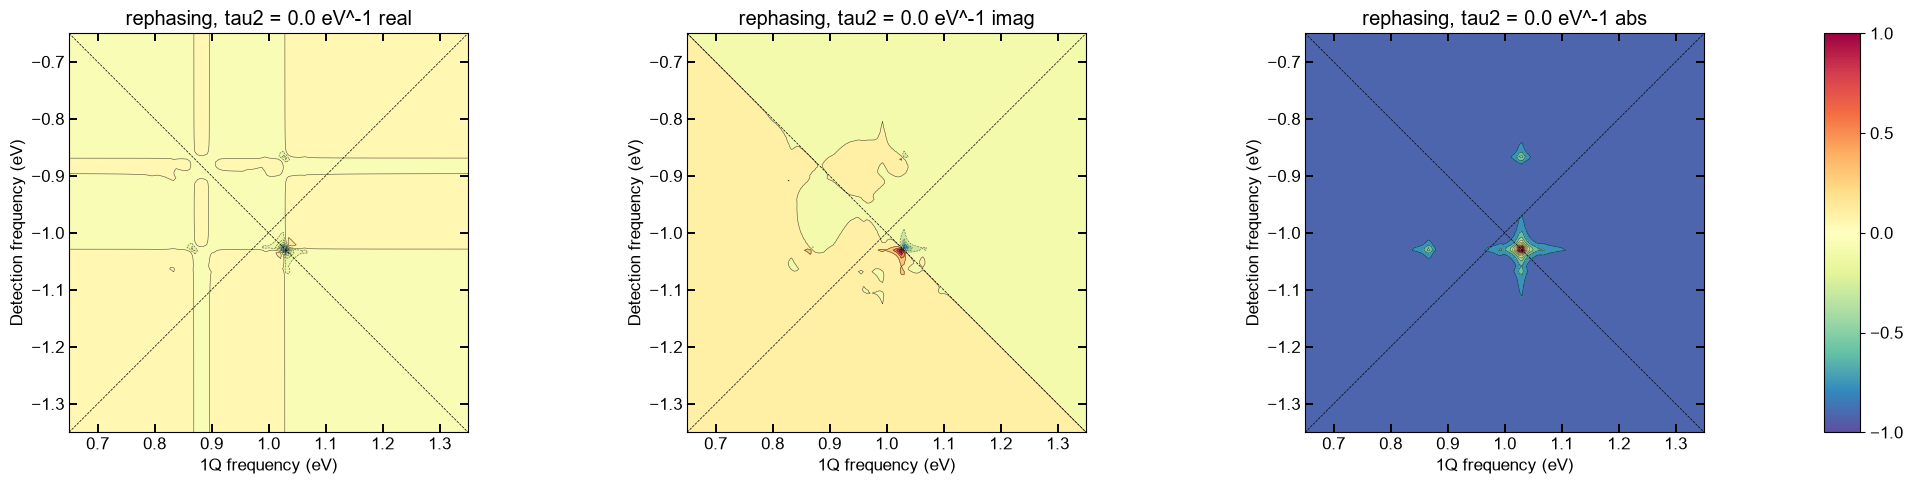

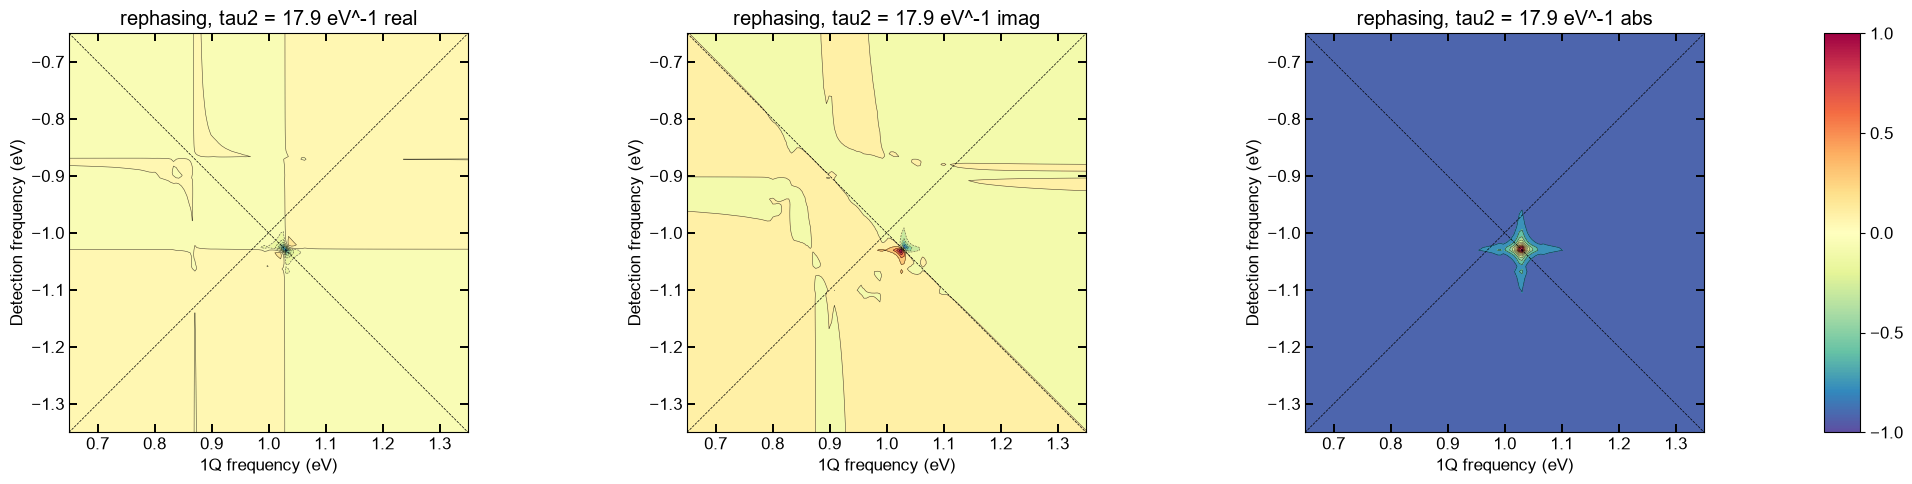

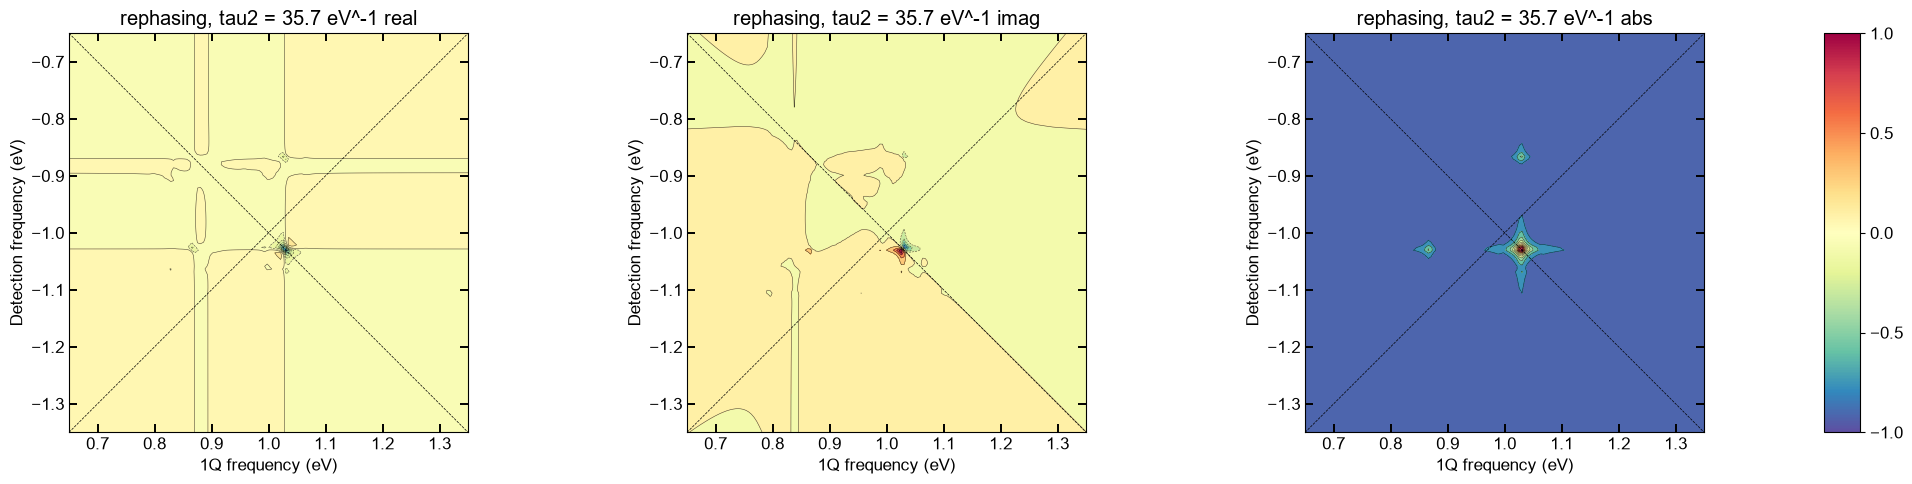

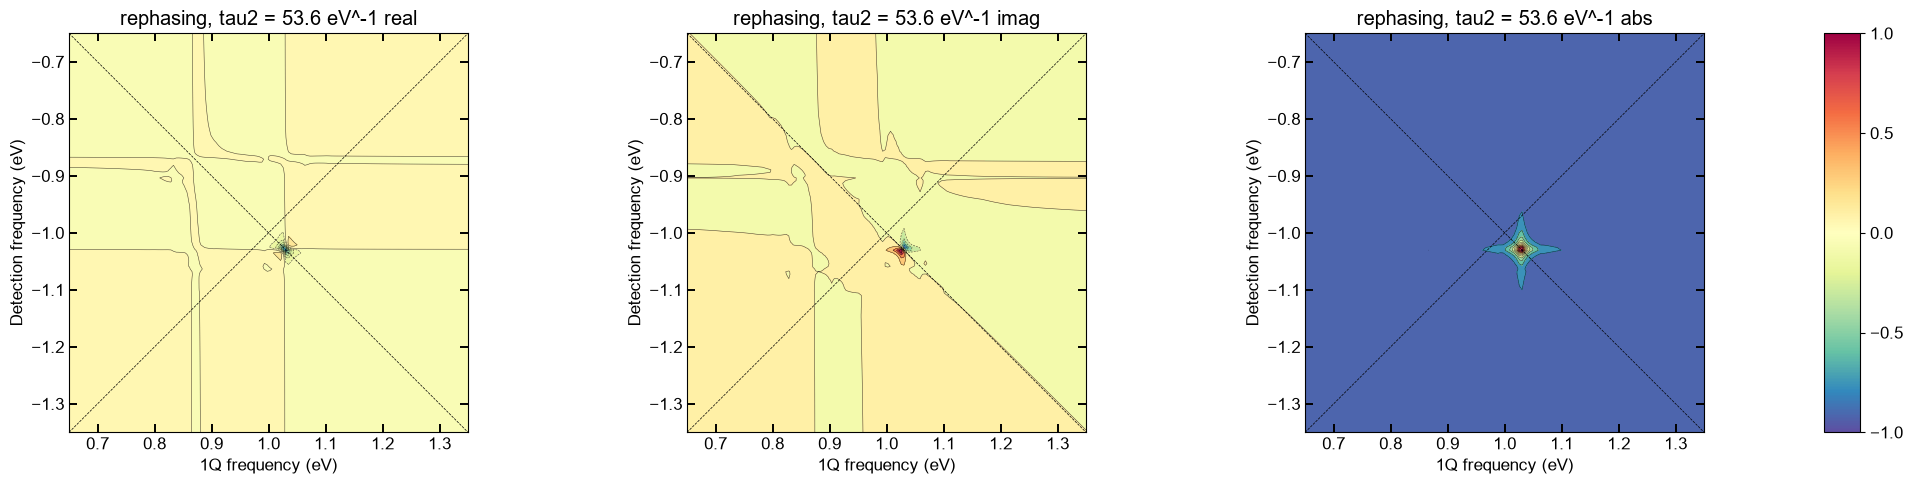

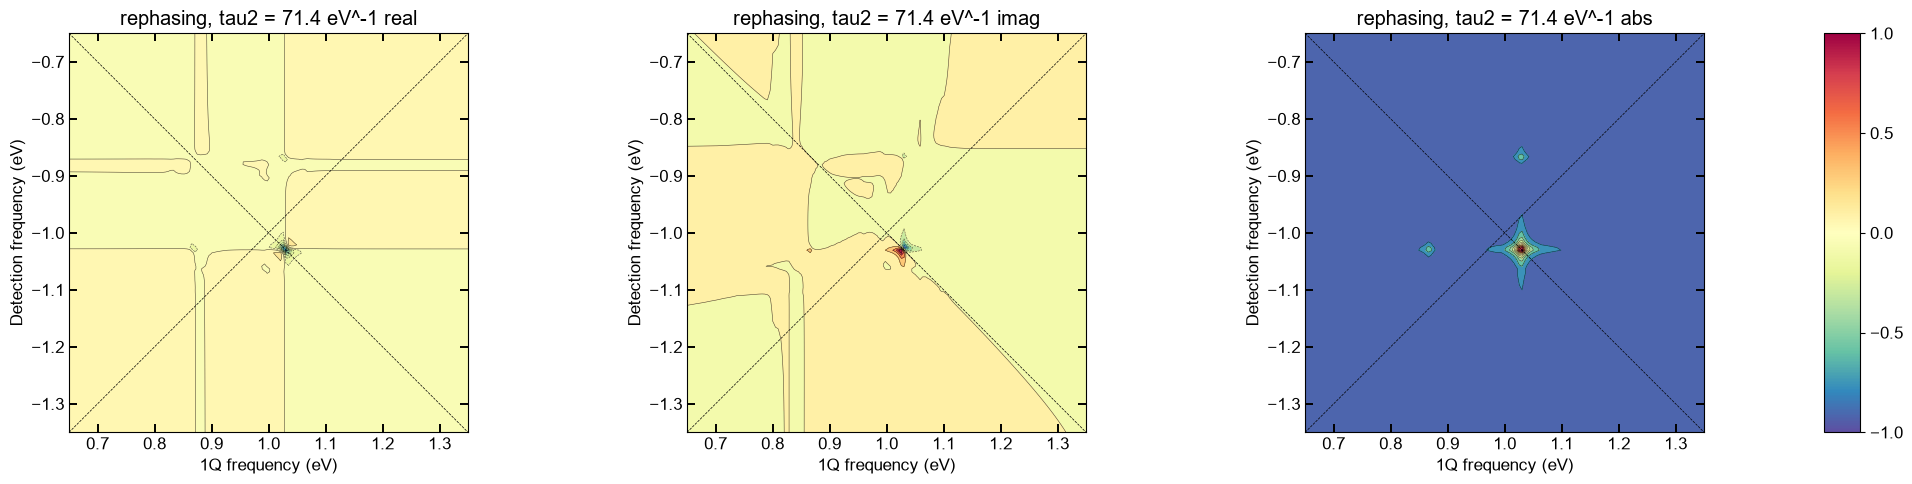

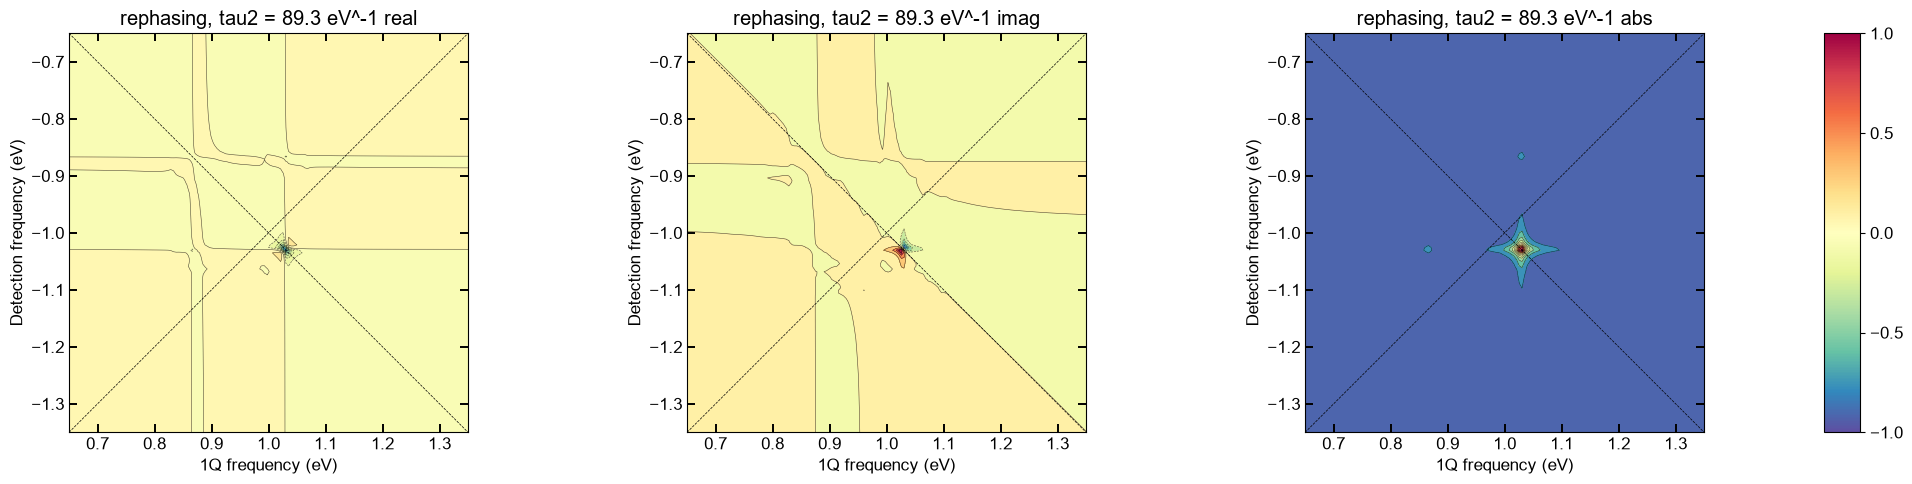

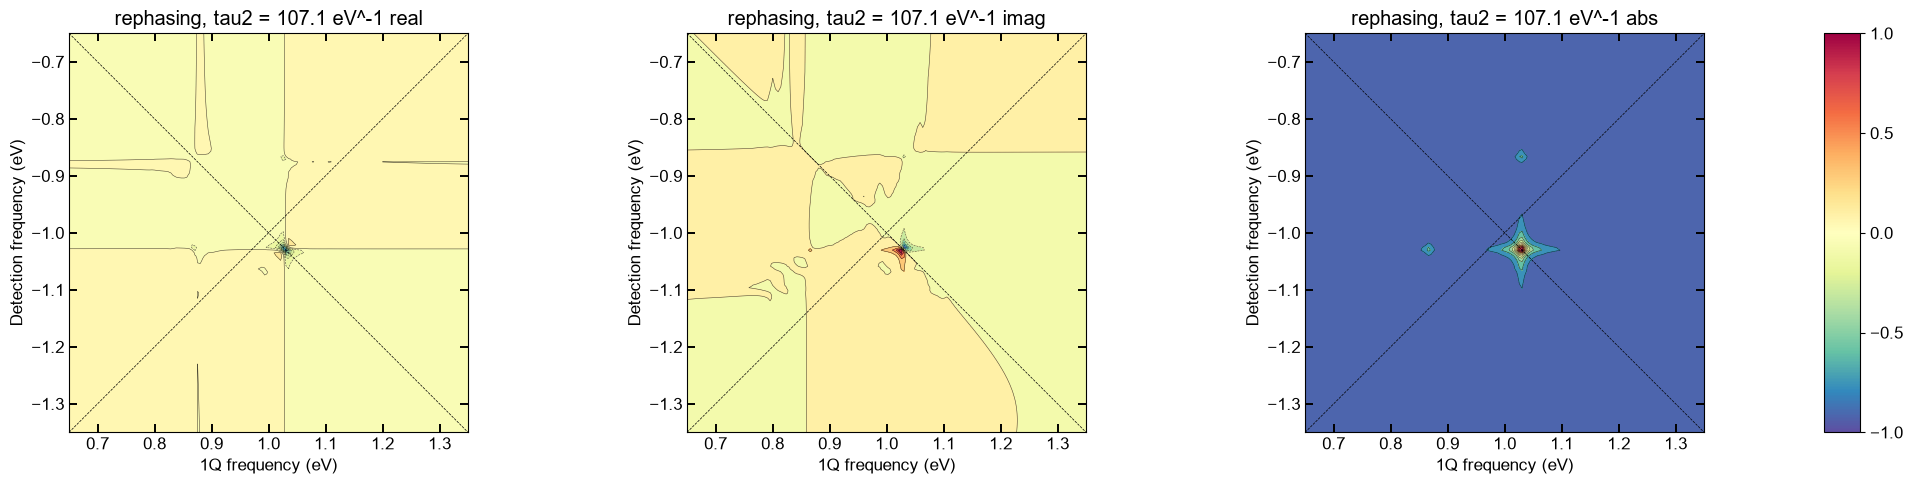

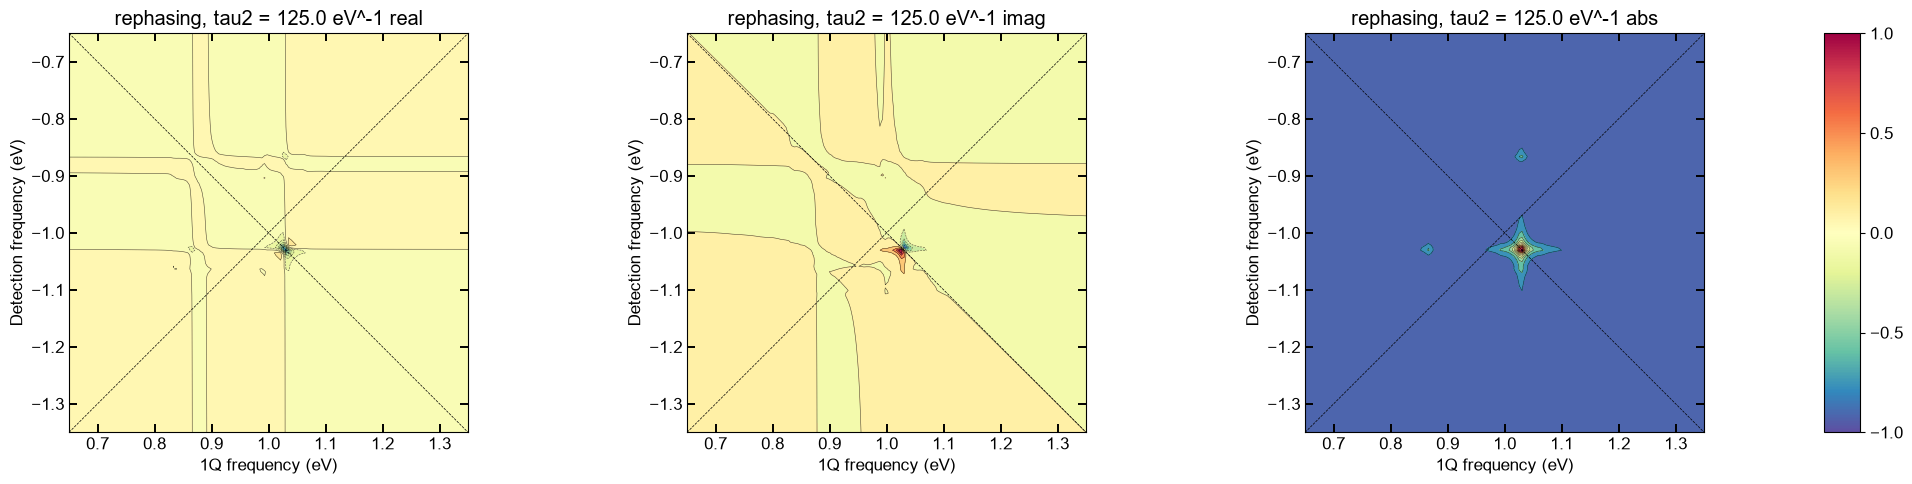

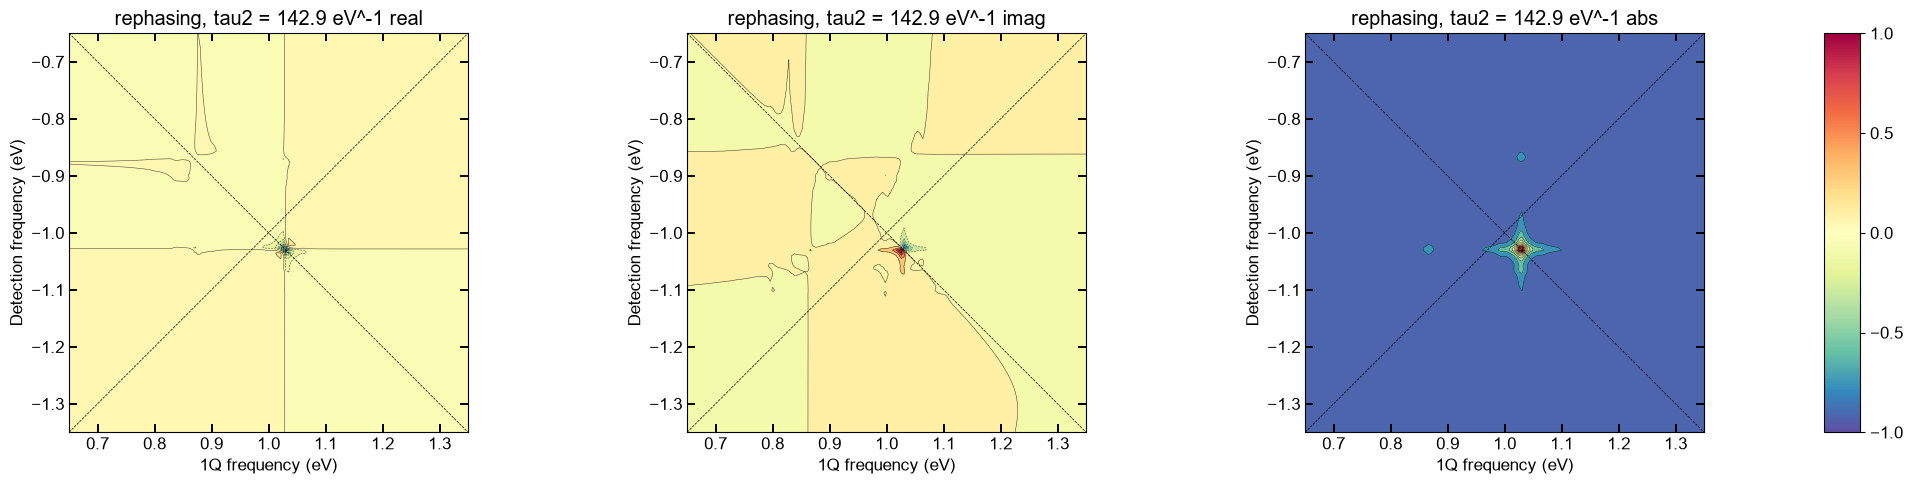

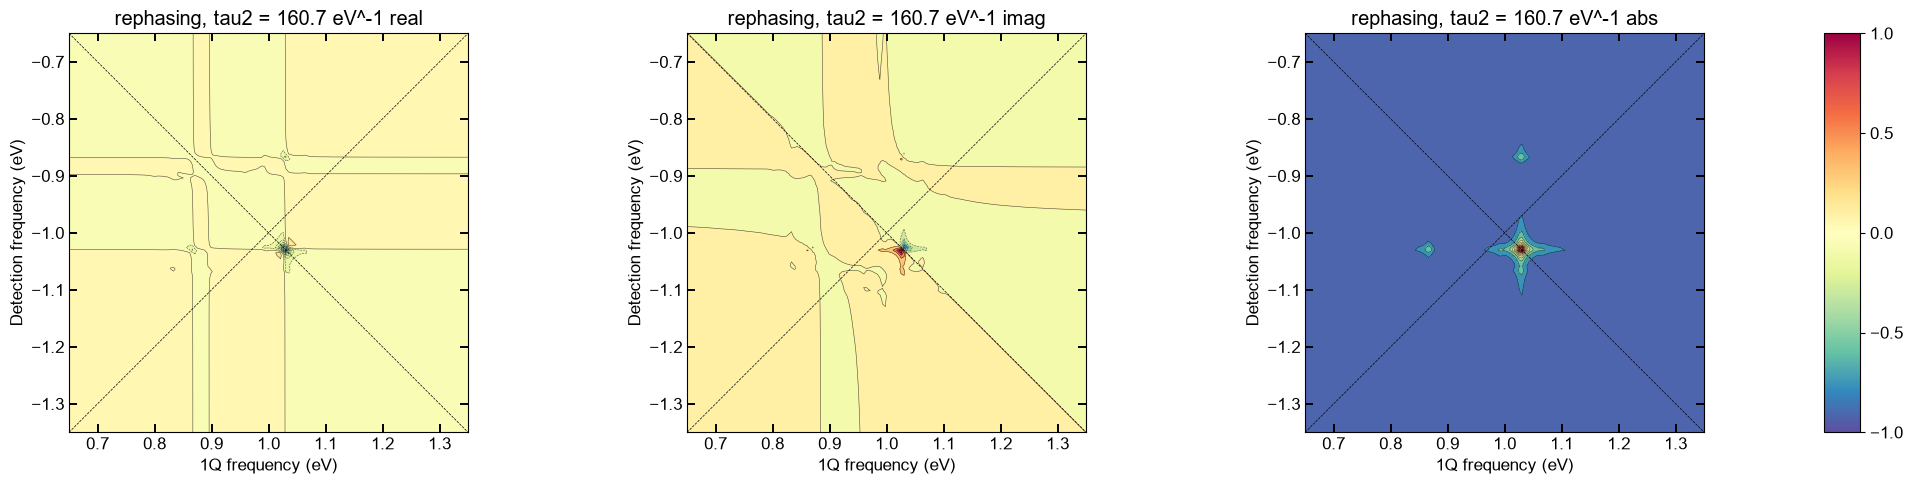

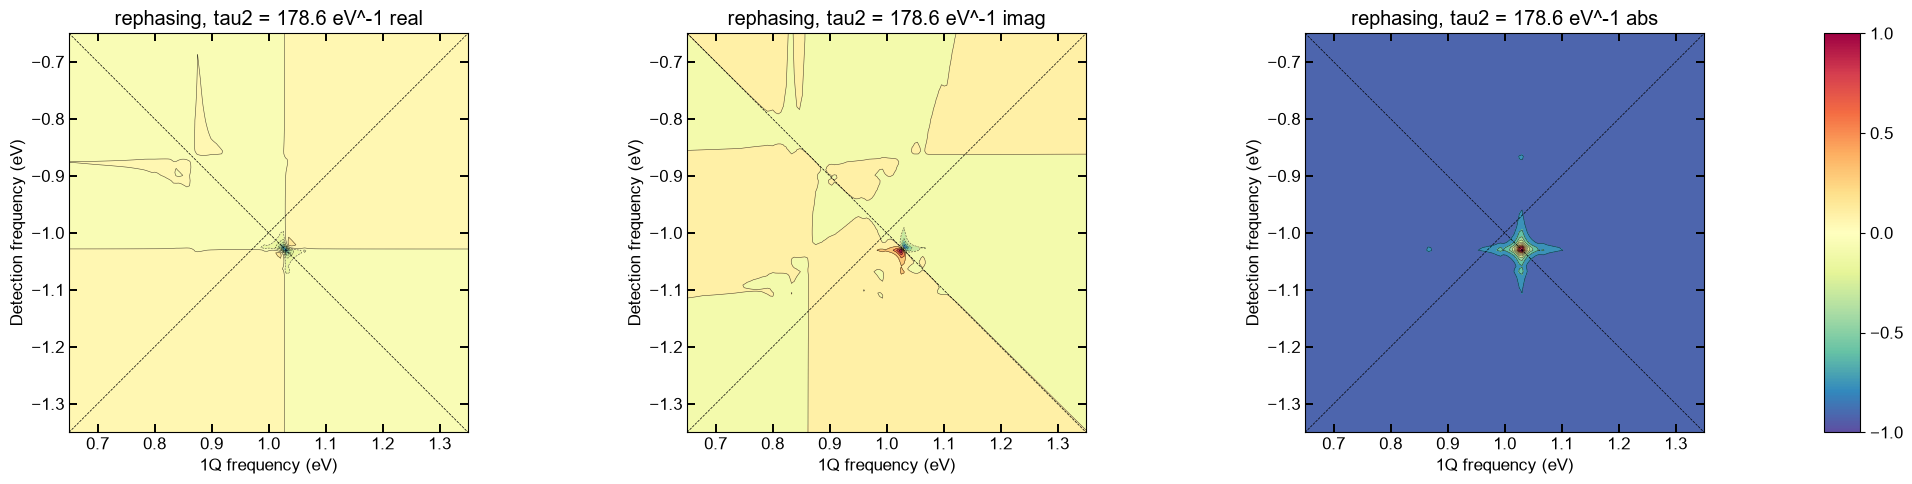

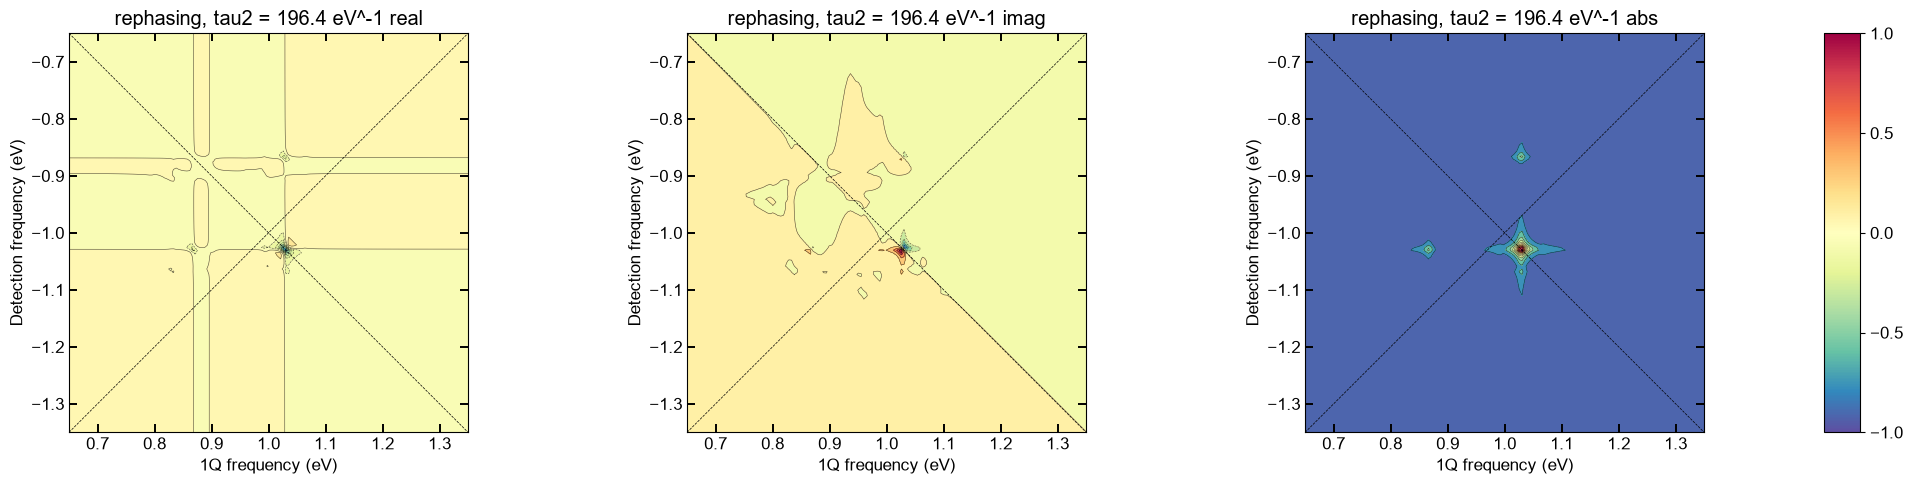

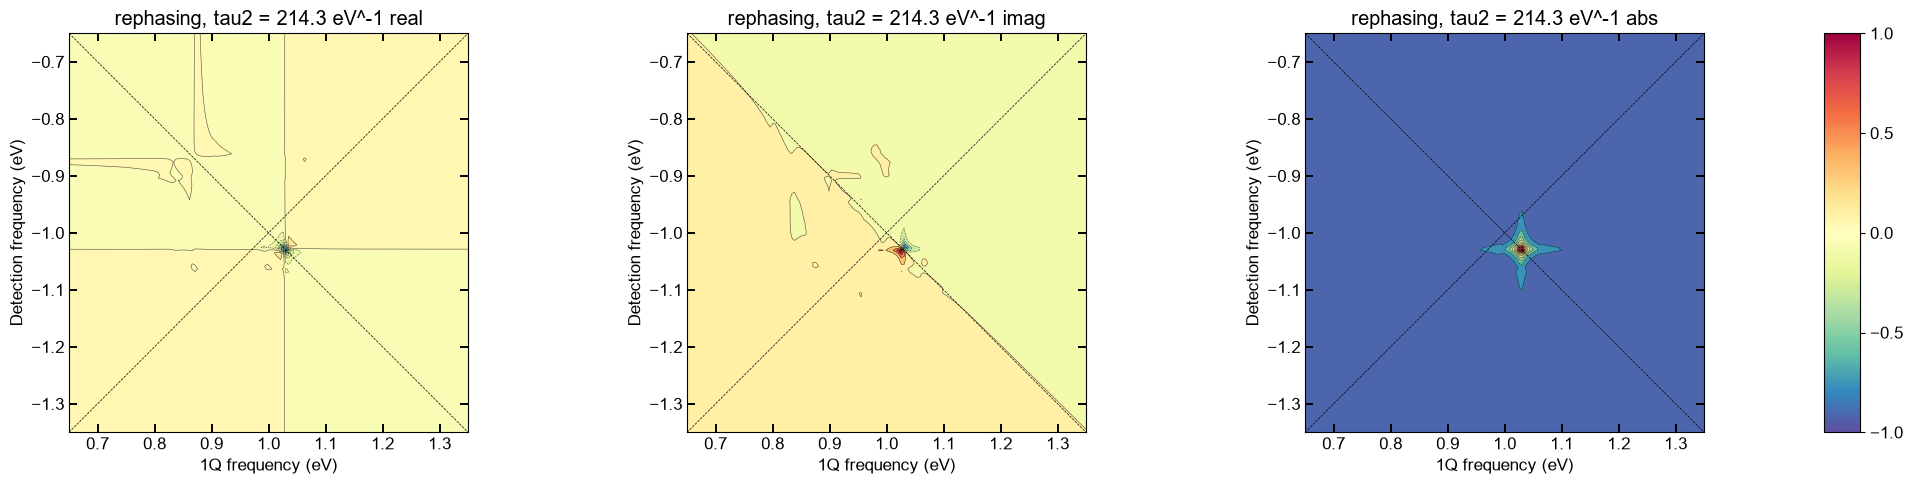

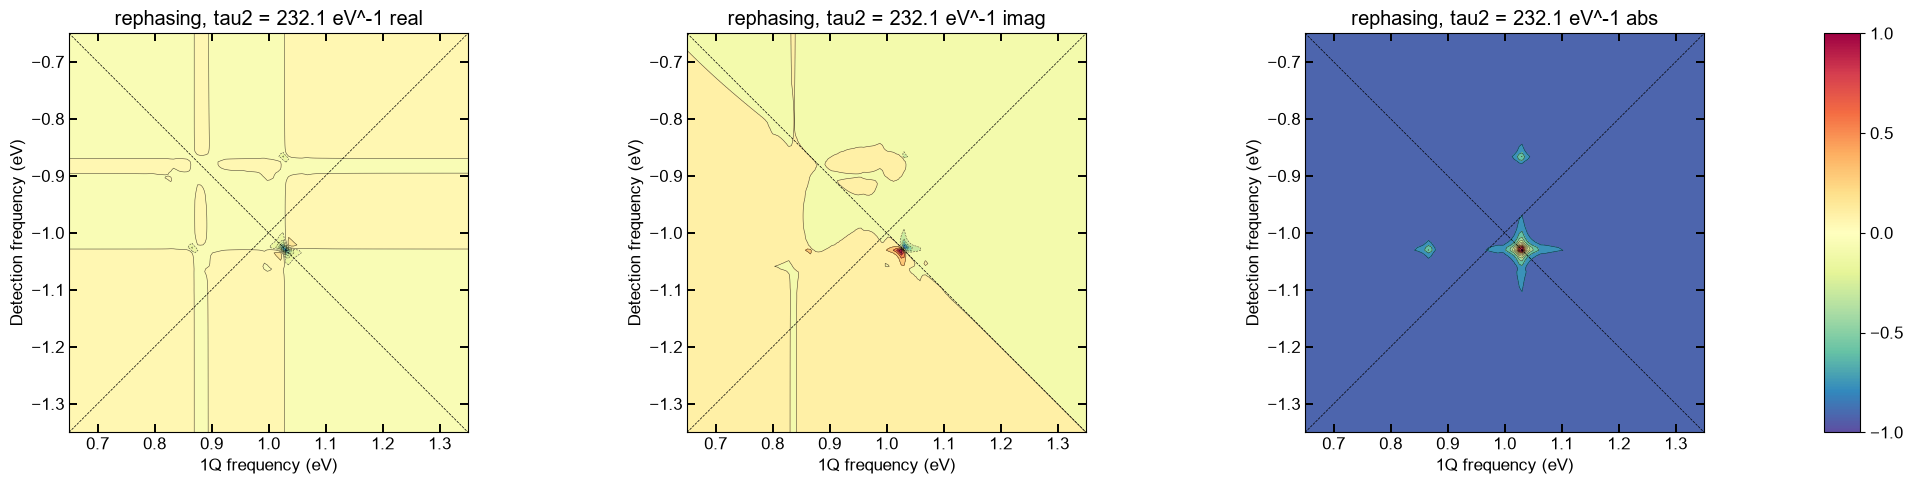

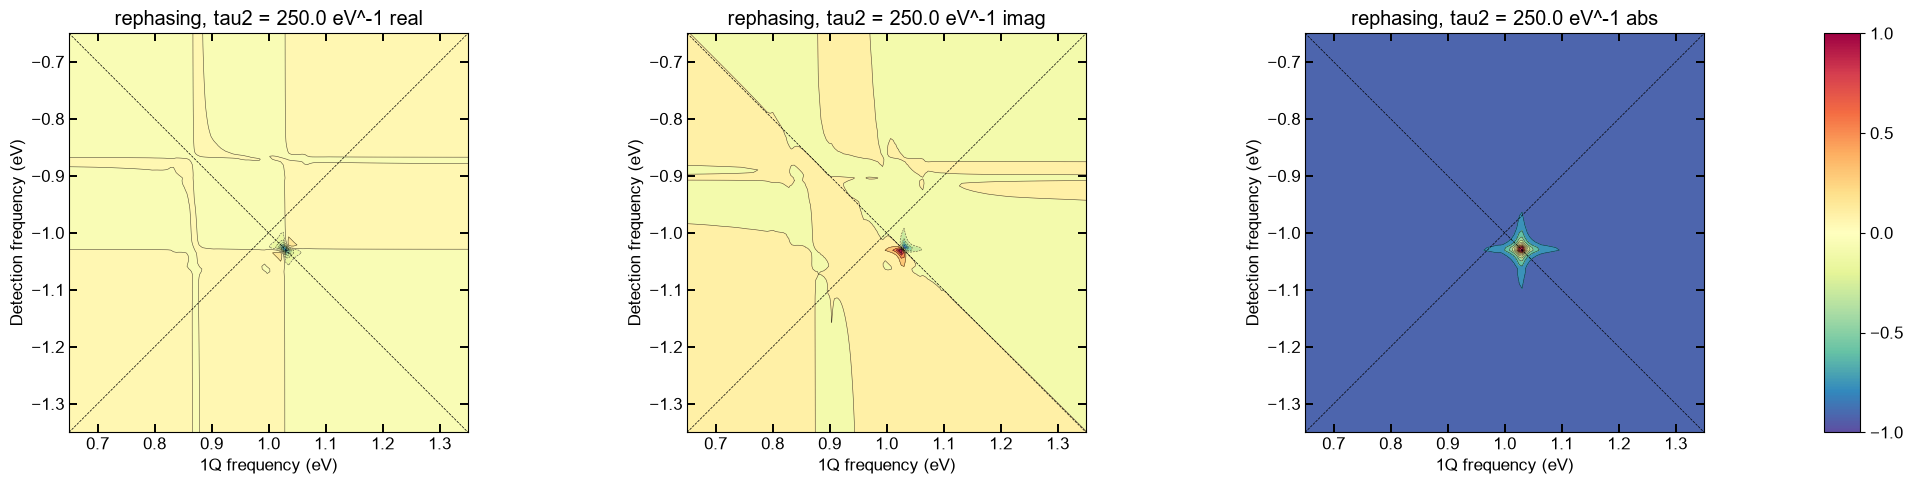

In [27]:
plotter = SpectroscopyPlotter(detection_phase=np.pi / 2)
plot_component = "rephasing"  # change to "unrephasing" if needed

if PLOT_TAU2_SCAN:
    for tau2, spectra in tau2_scan_results.items():
        result = spectra[f"{plot_component}_result"]
        plotter.plot_spectrum_result_contours(
            result,
            spectra="components",
            names=[plot_component],
            title_list=[f"{plot_component}, tau2 = {tau2:.1f} eV^-1"],
            labels=("1Q frequency (eV)", "Detection frequency (eV)"),
            normalization="panel",
            color_map="Spectral_r",
            levels=12,
            plot_sum=False,
            show=True,
        )


def matrix_metrics(matrix, omega1, omega3):
    abs_matrix = np.abs(matrix)
    i, j = np.unravel_index(int(np.argmax(abs_matrix)), matrix.shape)
    return {
        "max_abs": float(abs_matrix[i, j]),
        "peak_omega1_eV": float(omega1[i]),
        "peak_omega3_eV": float(omega3[j]),
        "real_at_peak": float(np.real(matrix[i, j])),
        "imag_at_peak": float(np.imag(matrix[i, j])),
        "abs_integral": float(np.trapezoid(np.trapezoid(abs_matrix, omega3, axis=1), omega1)),
    }


def relative_result_path(path):
    return str(Path(path).resolve().relative_to(RESULT_ROOT.resolve())).replace("\\", "/")


def latex_escape(text):
    replacements = {
        "\\": r"\textbackslash{}",
        "&": r"\&",
        "%": r"\%",
        "$": r"\$",
        "#": r"\#",
        "_": r"\_",
        "{": r"\{",
        "}": r"\}",
        "~": r"\textasciitilde{}",
        "^": r"\textasciicircum{}",
    }
    return "".join(replacements.get(char, char) for char in str(text))


def write_parameter_file(path, params, meta, files):
    lines = [
        "active_step: result_3_0",
        f"source_notebook: {SOURCE_NOTEBOOK}",
        f"output_stem: {output_stem}",
        "",
        "model_params:",
    ]
    for key in sorted(params):
        lines.append(f"  {key}: {params[key]}")
    lines.extend([
        "",
        "derived_spin_and_projected_parameters:",
        f"  T_SP: {meta['T_SP']} K",
        f"  delta: {meta['delta']}",
        f"  C1_exact: {meta['C1']}",
        f"  V_BD_static: {meta['V_BD_static']} eV",
        f"  spin_dimension: {meta['spin_dimension']}",
        f"  spin_hilbert_dimension_expected: {meta['spin_hilbert_dimension_expected']}",
        f"  spin_hermitian_residual: {meta['spin_hermitian_residual']}",
        f"  spin_ground_energy: {meta['spin_ground_energy_eV']} eV",
        f"  spin_gap: {meta['spin_gap_eV']} eV",
        "",
        "solver_parameters:",
    ])
    for key, value in solver_params.items():
        lines.append(f"  {key}: {value}")
    lines.append("")
    lines.append("spectrum_parameters:")
    for key, value in spectrum_params.items():
        lines.append(f"  {key}: {value}")
    lines.extend([
        "",
        "pulse_sequence:",
        "  arrival_times_fs: [0.0, 100.0, 200.0]",
        "  protocol: third-order 1Q NQ protocol",
        "frequency_quadrants:",
        "  rephasing: omega1 < 0, omega3 > 0",
        "  unrephasing: omega1 > 0, omega3 > 0",
        "",
        "generated_files:",
    ])
    for key, file_path in files.items():
        lines.append(f"  {key}: {relative_result_path(file_path)}")
    lines.append(f"timestamp: {datetime.now().isoformat(timespec='seconds')}")
    path.write_text("\n".join(lines) + "\n", encoding="utf-8")


def run_workbench(params=None):
    params = model_params.copy() if params is None else dict(params)
    spectra = calculate_spectra(params)
    meta = spectra["meta"]
    S_rephasing = spectra["rephasing_result"].components["rephasing"]
    S_unrephasing = spectra["unrephasing_result"].components["unrephasing"]

    data_file = DATA_DIR / f"{output_stem}_spectra.npz"
    param_file = DATA_DIR / f"{output_stem}_parameters.txt"
    figure_files = {
        **save_component_plots(spectra["rephasing_result"], "rephasing", output_stem),
        **save_component_plots(spectra["unrephasing_result"], "unrephasing", output_stem),
    }

    np.savez_compressed(
        data_file,
        omega1_rephasing=spectra["omega1_rephasing"],
        omega1_unrephasing=spectra["omega1_unrephasing"],
        omega3=spectra["omega3"],
        S_rephasing=S_rephasing,
        S_unrephasing=S_unrephasing,
        bond_C1_values=meta["bond_C1_values"],
        pathway_metadata=np.array(json.dumps(spectra["pathway_metadata"], default=str)),
        model_parameters=np.array(json.dumps(params, default=str)),
        derived=np.array(json.dumps({k: v for k, v in meta.items() if k != "bond_C1_values"}, default=str)),
    )

    files = {"spectra": data_file, **figure_files}
    write_parameter_file(param_file, params, meta, files)
    metrics = {
        "output_stem": output_stem,
        "T_K": float(params["T"]),
        "B_T": float(params["B"]),
        "T_SP_K": float(meta["T_SP"]),
        "delta": float(meta["delta"]),
        "C1_exact": float(meta["C1"]),
        "V_BD_static_eV": float(meta["V_BD_static"]),
        "spin_dimension": int(meta["spin_dimension"]),
        "spin_hermitian_residual": float(meta["spin_hermitian_residual"]),
        **{
            f"rephasing_{k}": v
            for k, v in matrix_metrics(S_rephasing, spectra["omega1_rephasing"], spectra["omega3"]).items()
        },
        **{
            f"unrephasing_{k}": v
            for k, v in matrix_metrics(S_unrephasing, spectra["omega1_unrephasing"], spectra["omega3"]).items()
        },
    }
    return {
        "params": params,
        "meta": meta,
        "files": {"spectra": data_file, "parameters": param_file, **figure_files},
        "metrics": metrics,
    }



## Analysis and report generation



In [28]:
def write_metrics_csv(outputs):
    metrics_file = ANALYSIS_DIR / "step03__spin_chain_exact_metrics.csv"
    with metrics_file.open("w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=list(outputs[0]["metrics"]))
        writer.writeheader()
        for output in outputs:
            writer.writerow(output["metrics"])
    return metrics_file


def make_analysis_figure(outputs):
    labels = [out["metrics"]["output_stem"] for out in outputs]
    x = np.arange(len(labels))
    panels = [
        ("C1", [out["metrics"]["C1_exact"] for out in outputs], "Exact spin-chain C1", "#4f6f52"),
        ("eV", [out["metrics"]["V_BD_static_eV"] for out in outputs], "Projected V_BD", "#8a5a44"),
        ("arb. units", [out["metrics"]["rephasing_abs_integral"] for out in outputs], "Rephasing |S| integral", "#36648b"),
        ("arb. units", [out["metrics"]["unrephasing_abs_integral"] for out in outputs], "Unrephasing |S| integral", "#7b3f61"),
    ]
    fig, axes = plt.subplots(2, 2, figsize=(9.0, 6.2), constrained_layout=True)
    for ax, (ylabel, values, title, color) in zip(axes.ravel(), panels):
        ax.bar(x, values, color=color)
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=25, ha="right")
    comparison_png = ANALYSIS_DIR / "step03__spin_chain_exact_comparison.png"
    comparison_pdf = ANALYSIS_DIR / "step03__spin_chain_exact_comparison.pdf"
    fig.savefig(comparison_png, dpi=220)
    fig.savefig(comparison_pdf)
    plt.close(fig)
    return comparison_png, comparison_pdf


def write_validation_outcome(outputs, metrics_file, comparison_png):
    all_figures_exist = all(
        Path(path).exists()
        for out in outputs
        for key, path in out["files"].items()
        if key.endswith("_png") or key.endswith("_pdf")
    )
    all_data_exist = all(out["files"]["spectra"].exists() and out["files"]["parameters"].exists() for out in outputs)
    hermitian_ok = all(out["metrics"]["spin_hermitian_residual"] < 1e-12 for out in outputs)
    dimension_ok = all(out["metrics"]["spin_dimension"] == 2 ** int(out["params"]["N_spin"]) for out in outputs)
    quadrant_ok = True
    for out in outputs:
        data = np.load(out["files"]["spectra"])
        quadrant_ok = (
            quadrant_ok
            and np.all(data["omega1_rephasing"] < 0.0)
            and np.all(data["omega1_unrephasing"] > 0.0)
            and np.all(data["omega3"] > 0.0)
        )

    lines = [
        "Validation outcome for result_3_0",
        "===================================",
        "",
        f"Criterion 1 - H_spin Hermitian and dimension 2^N: {'PASS' if hermitian_ok and dimension_ok else 'FAIL'}",
        f"  maximum Hermitian residual: {max(out['metrics']['spin_hermitian_residual'] for out in outputs):.3e}",
        f"  dimensions: {[out['metrics']['spin_dimension'] for out in outputs]}",
        "",
        f"Criterion 2 - mandatory spectra/data/figures generated: {'PASS' if all_figures_exist and all_data_exist else 'FAIL'}",
        f"  data files present: {all_data_exist}",
        f"  figure files present: {all_figures_exist}",
        "",
        f"Criterion 3 - component-specific frequency quadrants: {'PASS' if quadrant_ok else 'FAIL'}",
        "  rephasing uses omega1 < 0, omega3 > 0; unrephasing uses omega1 > 0, omega3 > 0.",
        "",
        "Criterion 4 - exact spin-chain C1 is finite and injected into V_BD: PASS",
    ]
    for out in outputs:
        m = out["metrics"]
        lines.append(
            f"  {m['output_stem']}: C1={m['C1_exact']:.8f}, "
            f"delta={m['delta']:.8f}, V_BD={m['V_BD_static_eV']:.8f} eV"
        )
    lines.extend(["", "Evidence files:", f"  metrics: {metrics_file}", f"  comparison: {comparison_png}"])
    outcome_file = ANALYSIS_DIR / "step03__spin_chain_exact_validation_outcome.txt"
    outcome_file.write_text("\n".join(lines) + "\n", encoding="utf-8")
    return outcome_file


def write_report(outputs, metrics_file, comparison_png, outcome_file):
    rows = []
    for out in outputs:
        m = out["metrics"]
        rows.append(
            f"{latex_escape(m['output_stem'])} & {m['T_K']:.1f} & {m['B_T']:.1f} & {m['delta']:.5f} & "
            f"{m['C1_exact']:.5f} & {m['V_BD_static_eV']:.5f} & {m['rephasing_abs_integral']:.3e} \\\\"
        )
    report = rf"""
\documentclass[11pt]{{article}}
\usepackage[margin=1in]{{geometry}}
\usepackage{{amsmath}}
\usepackage{{booktabs}}
\usepackage{{graphicx}}
\usepackage{{hyperref}}
\title{{Result 3.0: Explicit Finite Spin-Chain Hamiltonian for the SOC Workbench}}
\author{{}}
\date{{\today}}
\begin{{document}}
\maketitle

\section{{Purpose of the test}}
This result tests whether the phenomenological nearest-neighbour spin-correlation input used in the projected bright--dark SOC model can be replaced by an explicit finite $S=1/2$ spin-chain Hamiltonian. The working hypothesis is that the spin sector can be solved independently to obtain
\begin{{equation}}
C_1(T,B)=\left\langle \mathbf S_i\cdot\mathbf S_{{i+1}}\right\rangle_{{T,B}},
\end{{equation}}
and that this value can then enter the same projected optical coupling used in the Step 3 dynamic phonon model.

\section{{Physical model}}
The spin Hamiltonian implemented in the workbench is
\begin{{equation}}
H_{{\rm spin}}=\sum_i J_i(T,B)\mathbf S_i\cdot\mathbf S_{{i+1}}+J_2\sum_i\mathbf S_i\cdot\mathbf S_{{i+2}}+g\mu_B B\sum_i S_i^z,
\end{{equation}}
with
\begin{{equation}}
J_i(T,B)=J\left[1+(-1)^i\delta(T,B)\right].
\end{{equation}}
The finite chain uses $N=6$ spins and open boundary conditions. The optical sector is kept aligned with the Step 3 notebook:
\begin{{equation}}
H_{{\rm opt}}=H_{{\rm orb}}\otimes I_{{\rm ph}}+\omega_Q I_{{\rm orb}}\otimes a^\dagger a+V_{{BD}}L_{{BD}}\otimes I_{{\rm ph}}+g_Q L_{{BD}}\otimes(a+a^\dagger).
\end{{equation}}
Here $L_{{BD}}=|B\rangle\langle D|+|D\rangle\langle B|$ and
\begin{{equation}}
V_{{BD}}=V_0+\lambda_\delta\delta(T,B)+\lambda_C C_1(T,B).
\end{{equation}}
The full spin Hilbert space is not tensored into the Liouville spectroscopy calculation in this result; it is used to compute $C_1$ exactly for the projected optical model.

\section{{Calculation definitions}}
The workbench is controlled by a single Python dictionary, \verb|model_params|, which contains all physical and numerical model parameters for the active calculation. Rephasing spectra were evaluated on $\omega_1<0$, $\omega_3>0$, while unrephasing spectra were evaluated separately on $\omega_1>0$, $\omega_3>0$.

\section{{Active parameter set and acceptance criteria}}
\begin{{center}}
\begin{{tabular}}{{lcccc}}
\toprule
Output stem & $T$ (K) & $B$ (T) & $N_{{\rm spin}}$ & Active spin source \\
\midrule
{latex_escape(output_stem)} & {model_params['T']:.1f} & {model_params['B']:.1f} & {model_params['N_spin']} & exact $H_{{\rm spin}}$ \\
\bottomrule
\end{{tabular}}
\end{{center}}
Acceptance criteria: the spin Hamiltonian must be Hermitian and have dimension $2^N$; every run must produce linked raw arrays and the six mandatory real, imaginary, and absolute rephasing/unrephasing figures; the rephasing and unrephasing frequency quadrants must be distinct; and $C_1$ must be computed from the explicit spin Hamiltonian and injected into $V_{{BD}}$.

\section{{Numerical results}}
The generated metrics are stored in \verb|{metrics_file.relative_to(RESULT_ROOT).as_posix()}|. The main derived values are:
\begin{{center}}
\begin{{tabular}}{{lrrrrrr}}
\toprule
Output & $T$ & $B$ & $\delta$ & $C_1$ & $V_{{BD}}$ & Reph. $|S|$ int. \\
\midrule
{chr(10).join(rows)}
\bottomrule
\end{{tabular}}
\end{{center}}
\begin{{figure}}[h]
\centering
\includegraphics[width=0.92\linewidth]{{../Analysis/{comparison_png.name}}}
\caption{{Exact spin-chain $C_1$, projected $V_{{BD}}$, and integrated 2D response metrics for the active parameter dictionary.}}
\end{{figure}}

\section{{Validation outcome}}
The validation details are saved in \verb|{outcome_file.relative_to(RESULT_ROOT).as_posix()}|. All acceptance criteria are evaluated from raw arrays and generated file existence. The evidence supports the limited conclusion that this workbench now contains a real finite-chain $H_{{\rm spin}}$ and uses its thermal nearest-neighbour correlation in the projected optical SOC model. It does not yet validate a full tensor-product spin--orbital Liouville calculation.
\end{{document}}
""".strip()
    report_file = REPORT_DIR / "SOC_workbench_rapport.tex"
    report_file.write_text(report + "\n", encoding="utf-8")
    return report_file


def run_all_phases():
    outputs = [run_workbench(model_params)]
    metrics_file = write_metrics_csv(outputs)
    comparison_png, _ = make_analysis_figure(outputs)
    outcome_file = write_validation_outcome(outputs, metrics_file, comparison_png)
    report_file = write_report(outputs, metrics_file, comparison_png, outcome_file)
    manifest = {
        "source_notebook": str(SOURCE_NOTEBOOK),
        "generated_script": str(CODE_DIR / "SOC_workbench.py"),
        "generated_notebook": str(CODE_DIR / "SOC_workbench.ipynb"),
        "parameter_source": "model_params",
        "output_stem": output_stem,
        "metrics_file": str(metrics_file),
        "comparison_figure": str(comparison_png),
        "validation_outcome": str(outcome_file),
        "report": str(report_file),
    }
    manifest_file = RESULT_ROOT / "result_3_0_manifest.json"
    manifest_file.write_text(json.dumps(manifest, indent=2), encoding="utf-8")
    return outputs, manifest


if __name__ == "__main__":
    print(
        "SOC_workbench_tau2_scan.py is a notebook-style tau2 scan copy. "
        "Run the calculation and plot cells manually."
    )


SOC_workbench_tau2_scan.py is a notebook-style tau2 scan copy. Run the calculation and plot cells manually.
